
# CASO 3 — Auditoría de Asistencia Mensual (ChasquiFest)
### Operación ChasquiFest · Auditor de Visualización

**Dataset:** `../data/caso3_asistencia_mensual_chasquifest.csv` — granularidad **una fila por mes × sede** (372 filas = 31 meses × 12 sedes, ene-2024 a jul-2026).

**Campos clave:** `mes`, `anio`, `numero_mes`, `sede_id`, `dias_observados`/`dias_del_mes` (completitud), `cobertura_periodo_pct`, `asistentes` (volumen **observado**, no proyectado), `meta_asistentes` (ya ajustada a los días observados), `evento_contexto` (marca el quiebre ficticio).

**El disparador del caso:** el editor compara julio-2026 (corte a 12 días) contra julio-2025 **completo** (31 días) y anuncia una caída de 57%. Esta auditoría verifica esa cifra, la contextualiza y ofrece una comparación homóloga válida.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 20)

df = pd.read_csv('../data/caso3_asistencia_mensual_chasquifest.csv', parse_dates=['mes'])

print("Shape:", df.shape)
print("Columnas:", df.columns.tolist())
print("Sedes:", df['sede_id'].nunique(), "| Rango:", df['mes'].min().date(), "->", df['mes'].max().date())
df.head(3)


Shape: (372, 15)
Columnas: ['mes', 'anio', 'numero_mes', 'sede_id', 'ciudad', 'departamento', 'macrozona', 'dias_observados', 'dias_del_mes', 'cobertura_periodo_pct', 'asistentes', 'meta_asistentes', 'cancelaciones', 'ingresos_soles', 'evento_contexto']
Sedes: 12 | Rango: 2024-01-01 -> 2026-07-01


,mes,anio,numero_mes,sede_id,ciudad,departamento,macrozona,dias_observados,dias_del_mes,cobertura_periodo_pct,asistentes,meta_asistentes,cancelaciones,ingresos_soles,evento_contexto
0,2024-01-01,2024,1,SED-01,Lima,Lima,Costa,31,31,100.0,31035,33300,1226,1130785.91,Sin quiebre registrado
1,2024-01-01,2024,1,SED-02,Piura,Piura,Costa,31,31,100.0,17974,17020,636,635927.85,Sin quiebre registrado
2,2024-01-01,2024,1,SED-03,Trujillo,La Libertad,Costa,31,31,100.0,16557,18130,435,576260.95,Sin quiebre registrado


## 0. Verificación de números ancla (julio 2025 vs julio 2026)

In [2]:

jul25 = df[(df['anio']==2025) & (df['numero_mes']==7)]
jul26 = df[(df['anio']==2026) & (df['numero_mes']==7)]

tot25 = jul25['asistentes'].sum()
tot26 = jul26['asistentes'].sum()
d25   = jul25['dias_observados'].iloc[0]   # escalar: igual para las 12 sedes en ese mes
d26   = jul26['dias_observados'].iloc[0]
cob26 = jul26['cobertura_periodo_pct'].iloc[0]

caida_bruta = (tot26 - tot25) / tot25 * 100

ritmo25 = tot25 / d25
ritmo26 = tot26 / d26
cambio_ritmo = (ritmo26 - ritmo25) / ritmo25 * 100

print(f"Jul-2025: dias_observados={d25}/31 (cobertura 100%)  | total asistentes = {tot25:,}")
print(f"Jul-2026: dias_observados={d26}/31 (cobertura {cob26}%) | total asistentes = {tot26:,}")
print()
print(f"CAIDA BRUTA (total-de-mes vs total-de-mes) = ({tot26:,} - {tot25:,}) / {tot25:,} = {caida_bruta:.2f}%   <- el titular del editor")
print()
print(f"Ritmo diario 2025 = {tot25:,} / {d25} = {ritmo25:,.2f} asistentes/dia")
print(f"Ritmo diario 2026 = {tot26:,} / {d26} = {ritmo26:,.2f} asistentes/dia")
print(f"CAMBIO DE RITMO DIARIO = ({ritmo26:,.2f} - {ritmo25:,.2f}) / {ritmo25:,.2f} = {cambio_ritmo:+.2f}%   <- el dato corregido por cobertura")


Jul-2025: dias_observados=31/31 (cobertura 100%)  | total asistentes = 281,044
Jul-2026: dias_observados=12/31 (cobertura 38.71%) | total asistentes = 121,281

CAIDA BRUTA (total-de-mes vs total-de-mes) = (121,281 - 281,044) / 281,044 = -56.85%   <- el titular del editor

Ritmo diario 2025 = 281,044 / 31 = 9,065.94 asistentes/dia
Ritmo diario 2026 = 121,281 / 12 = 10,106.75 asistentes/dia
CAMBIO DE RITMO DIARIO = (10,106.75 - 9,065.94) / 9,065.94 = +11.48%   <- el dato corregido por cobertura



## Pregunta 1 — Componentes de la serie

### (1) Concepto técnico
Toda serie mensual observada se descompone en **tendencia** (nivel de largo plazo), **estacionalidad** (patrón que se repite cada año en los mismos meses), **ruido** (variación mes a mes no explicada por lo anterior) y, cuando existe, un **quiebre estructural** (choque puntual y localizado que no es ni tendencia ni estacionalidad). Julio-2026 exige además un quinto concepto: **cobertura/completitud del periodo** — un mes con `dias_observados < dias_del_mes` no es un valor de la serie comparable con un mes cerrado; es una medición parcial.

### (2) Evidencia con números reales del CSV

**Tendencia (leve alza):** total anual `asistentes` 2024 = 2,471,862 → 2025 = 2,703,721 (+9.38%). Los 12 meses de 2025 superan a su homólogo 2024 sin excepción (mínimo +3.60% en abril, máximo +15.58% en febrero) — ver tabla de abajo. Notable: incluso marzo–mayo 2025 (meses del quiebre) crecen vs. 2024 — mar: 203,347 vs 182,929 = +11.16%; abr: 202,776 vs 195,726 = +3.60%; may: 201,999 vs 190,133 = +6.24% — porque el quiebre solo golpea 2 de 12 sedes; a nivel agregado la tendencia de fondo no se rompe (ver tabla de abajo para el resto de meses).

**Estacionalidad (picos jul/dic):** en 2025, julio = 281,044 y diciembre = 321,462, frente a una base de meses no-pico que oscila entre 183,751 (feb) y 226,442 (nov), media ≈ 210,122. El mismo patrón se repite en 2024 (jul = 250,847, dic = 292,448, vs base ~180–210k). Es estructural y recurrente cada año.

**Ruido:** oscilación mes a mes sin patrón, p.ej. 2025: ene 206,593 → feb 183,751 (−11.06%) → mar 203,347 (+10.66%). Fluctuación de corto plazo no atribuible a tendencia ni estación.

**Quiebre (Loreto/Ucayali, mar–may 2025):** SED-11 (Iquitos) y SED-12 (Pucallpa) muestran `evento_contexto = "Interrupción logística ficticia"` en exactamente 6 de 372 filas (2025-03, 2025-04, 2025-05). Iquitos: 8,518 / 8,485 / 7,459 asistentes (vs. su propio enero-2025 = 13,411, es decir índice ≈63.5/63.3/55.6 sobre base 100). Pucallpa: 7,429 / 7,109 / 7,147 (vs. enero-2025 = 11,242, índice ≈66.1/63.2/63.6). Ambas sedes se recuperan en junio-2025 (Iquitos 13,665 = índice 101.9; Pucallpa 11,520 = índice 102.5). Es un evento localizado y temporal (forma de "V"), no una tendencia estructural nueva; el resto de sedes y meses = "Sin quiebre registrado" (366/372 filas), y en 2026 ambas sedes vuelven a "Sin quiebre registrado" en las 14 filas correspondientes.

**Julio 2026:** `dias_observados=12`, `dias_del_mes=31`, `cobertura_periodo_pct=38.71%`, total asistentes = 121,281.

### (3) Decisión de cálculo/diseño — cómo se clasifica julio-2026
Julio-2026 **no se etiqueta automáticamente como "caída" ni como "outlier"**:
- Para sostener **"caída"** se necesita una comparación entre periodos *homólogos* (misma cobertura). Comparar el total de 12 días contra el total de 31 días del año anterior (`LOOKUP(..., -12)` ingenuo) no es una comparación homóloga — ver Pregunta 3.
- Para sostener **"outlier"** primero hay que descartar que la anomalía se explique por cobertura. Aquí se explica enteramente por cobertura: `cobertura_periodo_pct=38.71%` es el único campo que difiere estructuralmente de cualquier otro julio en el dataset (todos los demás meses de la serie tienen cobertura 100%, ver chequeo abajo).
- Diagnóstico correcto: **periodo truncado / observación incompleta**, no un evento del negocio.

**Titular inicial (el que produce el gráfico ingenuo):** *"Julio se desploma 57%: la asistencia colapsa en ChasquiFest."*

**Titular revisado (tras revisar `cobertura_periodo_pct`):** *"Julio-2026 solo tiene 12 de 31 días registrados (38.71% de cobertura); al ritmo diario observado, la asistencia va +11.5% por encima de julio-2025."*

### (4) Límite/trade-off
Clasificar automáticamente por umbral (p.ej. "toda caída >50% es alerta roja") es peligroso si el pipeline de reporting no verifica `cobertura_periodo_pct` antes de calcular variaciones — el mismo dato genera una alerta falsa de crisis o una lectura correcta de crecimiento, dependiendo de si se audita la completitud primero.


In [3]:

# Tendencia: totales anuales y comparación mensual homóloga 2024 vs 2025
tot2024 = df[df['anio']==2024]['asistentes'].sum()
tot2025 = df[df['anio']==2025]['asistentes'].sum()
print(f"Total anual 2024 = {tot2024:,} | Total anual 2025 = {tot2025:,} | cambio = {(tot2025-tot2024)/tot2024*100:+.2f}%")
print()

t24 = df[df['anio']==2024].groupby('numero_mes')['asistentes'].sum()
t25 = df[df['anio']==2025].groupby('numero_mes')['asistentes'].sum()
comp = pd.DataFrame({'2024': t24, '2025': t25})
comp['cambio_%'] = (comp['2025'] - comp['2024']) / comp['2024'] * 100
print(comp.round(2))
print()
nonpeak = t25.drop([7,12])
print(f"Meses no-pico 2025 (excl. jul/dic): min={nonpeak.min():,} max={nonpeak.max():,} media={nonpeak.mean():,.0f}")


Total anual 2024 = 2,471,862 | Total anual 2025 = 2,703,721 | cambio = +9.38%

              2024    2025  cambio_%
numero_mes                          
1           187040  206593     10.45
2           158983  183751     15.58
3           182929  203347     11.16
4           195726  202776      3.60
5           190133  201999      6.24
6           196894  216514      9.96
7           250847  281044     12.04
8           200767  220092      9.63
9           201181  218069      8.39
10          205802  221632      7.69
11          209112  226442      8.29
12          292448  321462      9.92

Meses no-pico 2025 (excl. jul/dic): min=183,751 max=226,442 media=210,122


In [4]:

# Quiebre Loreto / Ucayali
quiebre = df[df['evento_contexto'] != 'Sin quiebre registrado']
print(f"Filas con quiebre marcado: {len(quiebre)} de {len(df)}")
print(quiebre[['mes','sede_id','ciudad','asistentes','meta_asistentes','evento_contexto']].to_string(index=False))
print()

# Indice base 100 (referencia enero-2025) para Loreto, Ucayali y Lima -> forma de V
base_ene25 = df[(df['anio']==2025)&(df['numero_mes']==1)].set_index('sede_id')['asistentes']
sub = df[(df['anio']==2025) & (df['sede_id'].isin(['SED-11','SED-12','SED-01']))].copy()
sub['indice_base100'] = sub.apply(lambda r: r['asistentes'] / base_ene25[r['sede_id']] * 100, axis=1)
print(sub[['mes','sede_id','ciudad','asistentes','indice_base100']].sort_values(['sede_id','mes']).round(1).to_string(index=False))


Filas con quiebre marcado: 6 de 372
       mes sede_id   ciudad  asistentes  meta_asistentes                 evento_contexto
2025-03-01  SED-11  Iquitos        8518            13748 Interrupción logística ficticia
2025-03-01  SED-12 Pucallpa        7429            12082 Interrupción logística ficticia
2025-04-01  SED-11  Iquitos        8485            13858 Interrupción logística ficticia
2025-04-01  SED-12 Pucallpa        7109            12179 Interrupción logística ficticia
2025-05-01  SED-11  Iquitos        7459            13968 Interrupción logística ficticia
2025-05-01  SED-12 Pucallpa        7147            12275 Interrupción logística ficticia

       mes sede_id   ciudad  asistentes  indice_base100
2025-01-01  SED-01     Lima       33551           100.0
2025-02-01  SED-01     Lima       30688            91.5
2025-03-01  SED-01     Lima       35692           106.4
2025-04-01  SED-01     Lima       33503            99.9
2025-05-01  SED-01     Lima       37888           112.9
2025

/tmp/ipykernel_696237/119038043.py:11: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(sub[['mes','sede_id','ciudad','asistentes','indice_base100']].sort_values(['sede_id','mes']).round(1).to_string(index=False))


In [5]:

# Chequeo de cobertura: julio-2026 es el UNICO periodo con cobertura < 100% en todo el dataset
cobertura_check = df.groupby(['anio','numero_mes'])['cobertura_periodo_pct'].first()
incompletos = cobertura_check[cobertura_check < 100]
print("Periodos con cobertura < 100% en TODO el dataset:")
print(incompletos)


Periodos con cobertura < 100% en TODO el dataset:
anio  numero_mes
2026  7             38.71
Name: cobertura_periodo_pct, dtype: float64


### Figura 1 — Comparar magnitudes vs. tasas: el titular bruto vs. la lectura corregida por ritmo diario

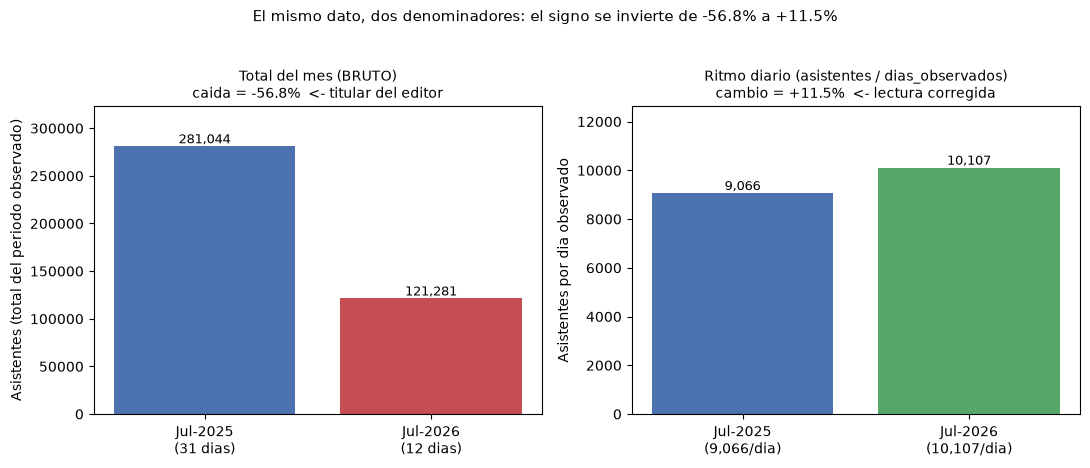

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Panel A: comparacion bruta (total del mes) -> lo que ve el editor
ax = axes[0]
bars = ax.bar(['Jul-2025\n(31 dias)', 'Jul-2026\n(12 dias)'], [tot25, tot26],
              color=['#4C72B0', '#C44E52'])
ax.set_title(f"Total del mes (BRUTO)\ncaida = {caida_bruta:.1f}%  <- titular del editor", fontsize=10)
ax.set_ylabel('Asistentes (total del periodo observado)')
for b, v in zip(bars, [tot25, tot26]):
    ax.text(b.get_x()+b.get_width()/2, v, f"{v:,.0f}", ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, tot25*1.15)

# Panel B: ritmo diario -> comparacion corregida por cobertura
ax = axes[1]
bars = ax.bar(['Jul-2025\n(9,066/dia)', 'Jul-2026\n(10,107/dia)'], [ritmo25, ritmo26],
              color=['#4C72B0', '#55A868'])
ax.set_title(f"Ritmo diario (asistentes / dias_observados)\ncambio = {cambio_ritmo:+.1f}%  <- lectura corregida", fontsize=10)
ax.set_ylabel('Asistentes por dia observado')
for b, v in zip(bars, [ritmo25, ritmo26]):
    ax.text(b.get_x()+b.get_width()/2, v, f"{v:,.0f}", ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, ritmo26*1.25)

fig.suptitle('El mismo dato, dos denominadores: el signo se invierte de -56.8% a +11.5%', fontsize=11, y=1.03)
plt.tight_layout()
plt.savefig('fig1_bruto_vs_ritmo.png', dpi=110, bbox_inches='tight')
plt.show()



## Pregunta 2 — Ventana, acumulado y dirección

### (1) Concepto técnico
Una **media móvil** (window function `WINDOW_AVG`) suaviza estacionalidad y ruido para leer la *dirección reciente* del nivel de la serie. Un **acumulado** (`RUNNING_SUM`) mide *progreso* hacia una meta dentro de una ventana temporal (típicamente el año) y por diseño es monótono no-decreciente si la métrica es siempre ≥0. Son respuestas a preguntas distintas y no deben graficarse en el mismo eje/línea sin aclarar la diferencia de semántica (uno es una "tasa/nivel", el otro es un "stock acumulado").

### (2) Fórmulas Tableau + declaración de addressing/partición/orden

**(a) Media móvil de 3 meses (total festival):**
```
WINDOW_AVG(SUM([asistentes]), -2, 0)
```
- **Addressing:** Along `Mes` (table-down si `Mes` está en filas / Pane down).
- **Partición:** por `Sede` si se quiere la media móvil de cada sede por separado; **sin partición por sede** (total festival) si se agregó primero `SUM([asistentes])` a nivel mes — este notebook usa el total festival.
- **Orden:** `Mes` ascendente (obligatorio para que `-2,0` tome "los 2 meses previos + el actual").
- **Símil pandas:** `serie.groupby('mes')['asistentes'].sum().sort_index().rolling(3).mean()`

**(b) Acumulado que reinicia cada año (YTD):**
```
RUNNING_SUM(SUM([asistentes]))
```
- **Addressing:** Along `Mes`.
- **Partición/reinicio:** compute using `Mes`, **restarting every `Año`** (el acumulado vuelve a 0 en enero de cada año).
- **Orden:** `Mes` ascendente dentro de cada `Año`.
- **Símil pandas:** `df.sort_values('mes').groupby('anio')['asistentes'].transform(lambda s: s.groupby(df['numero_mes']).sum())` → más simple: `serie.groupby('anio')['asistentes'].cumsum()` sobre la serie mensual ya agregada.

### (3) Decisión de diseño — por qué NO van en la misma línea, y cuál es KPI vs contexto
La media móvil responde **"¿cuál es la tendencia reciente?"** (nivel/dirección); el acumulado responde **"¿cuánto llevamos en el año?"** (progreso). Ponerlas en el mismo eje es engañoso: el acumulado casi siempre sube (es una suma), mientras que la media móvil puede subir o bajar — un lector que mira ambas líneas juntas tiende a anclarse en la que sube y descarta la que cae.

Para decidir la **programación del próximo mes**:
- **KPI decisor** = media móvil de 3 meses (o el YoY por ritmo diario homólogo de la Pregunta 3) — mide la dirección real y reciente.
- **Contexto** = acumulado YTD — sirve para verificar avance hacia la meta anual, no para decidir el mes siguiente.
- **Falsa tranquilidad** = el acumulado YTD, con evidencia concreta abajo: YTD-hasta-julio-2025 (mes completo) = 1,496,024; YTD-hasta-julio-2026 (mes truncado a 12 días) = 1,487,219 → diferencia de solo **−0.59%**. Un lector que solo mira el acumulado concluiría "vamos casi igual que el año pasado", ocultando que julio-2026 está truncado y que el ritmo corregido va **+11.5%** por encima. El acumulado diluye el problema (o, en este caso, diluye la buena noticia) porque 6 meses completos ya "amortiguan" cualquier mes parcial — y nunca puede bajar, así que jamás avisará de un verdadero deterioro hasta que ya sea muy tarde en el año.

### (4) Límite/trade-off
La media móvil de 3 meses retrasa la detección de un quiebre ~1–2 meses, y su último punto se contamina si el mes está truncado (jul-2026: cae a 199,654 al incluir el mes parcial, frente a 236,608 en jun-2026 con 3 meses completos) — no es una lectura limpia del nivel reciente cuando el mes más nuevo no ha cerrado. El YTD nunca decrece (es una suma acumulada de una métrica ≥0), así que por diseño no puede avisar de deterioros: en el peor escenario posible seguiría subiendo mes a mes aunque el negocio se esté desplomando, solo más lento.


In [7]:

# Serie mensual total festival: media movil 3m y acumulado YTD por año
serie = df.groupby('mes', as_index=False)['asistentes'].sum().sort_values('mes').reset_index(drop=True)
serie['anio'] = serie['mes'].dt.year
serie['media_movil_3m'] = serie['asistentes'].rolling(3).mean()          # WINDOW_AVG(SUM([asistentes]), -2, 0)
serie['ytd'] = serie.groupby('anio')['asistentes'].cumsum()              # RUNNING_SUM ... restarting every Anio

print(serie.to_string(index=False))


       mes  asistentes  anio  media_movil_3m     ytd
2024-01-01      187040  2024             NaN  187040
2024-02-01      158983  2024             NaN  346023
2024-03-01      182929  2024   176317.333333  528952
2024-04-01      195726  2024   179212.666667  724678
2024-05-01      190133  2024   189596.000000  914811
2024-06-01      196894  2024   194251.000000 1111705
2024-07-01      250847  2024   212624.666667 1362552
2024-08-01      200767  2024   216169.333333 1563319
2024-09-01      201181  2024   217598.333333 1764500
2024-10-01      205802  2024   202583.333333 1970302
2024-11-01      209112  2024   205365.000000 2179414
2024-12-01      292448  2024   235787.333333 2471862
2025-01-01      206593  2025   236051.000000  206593
2025-02-01      183751  2025   227597.333333  390344
2025-03-01      203347  2025   197897.000000  593691
2025-04-01      202776  2025   196624.666667  796467
2025-05-01      201999  2025   202707.333333  998466
2025-06-01      216514  2025   207096.333333 1

In [8]:

# Evidencia de "falsa tranquilidad" del acumulado
ytd_jul25 = serie.loc[serie['mes']=='2025-07-01', 'ytd'].values[0]
ytd_jul26 = serie.loc[serie['mes']=='2026-07-01', 'ytd'].values[0]
diff_ytd = (ytd_jul26 - ytd_jul25) / ytd_jul25 * 100
print(f"YTD hasta jul-2025 (mes completo)  = {ytd_jul25:,}")
print(f"YTD hasta jul-2026 (mes truncado)  = {ytd_jul26:,}")
print(f"Diferencia YTD = {diff_ytd:+.2f}%   <- casi imperceptible, pese a la caida bruta de -56.8% en julio")
print()

# Evidencia de que la media movil 3m TAMBIEN se distorsiona al mezclar un mes truncado
mm_jun26 = serie.loc[serie['mes']=='2026-06-01', 'media_movil_3m'].values[0]
mm_jul26 = serie.loc[serie['mes']=='2026-07-01', 'media_movil_3m'].values[0]
print(f"Media movil 3m en jun-2026 (3 meses completos) = {mm_jun26:,.0f}")
print(f"Media movil 3m en jul-2026 (incluye mes truncado) = {mm_jul26:,.0f}")
print("-> la media movil tambien debe leerse con cuidado cuando el ultimo punto de la ventana esta truncado.")


YTD hasta jul-2025 (mes completo)  = 1,496,024
YTD hasta jul-2026 (mes truncado)  = 1,487,219
Diferencia YTD = -0.59%   <- casi imperceptible, pese a la caida bruta de -56.8% en julio

Media movil 3m en jun-2026 (3 meses completos) = 236,608
Media movil 3m en jul-2026 (incluye mes truncado) = 199,654
-> la media movil tambien debe leerse con cuidado cuando el ultimo punto de la ventana esta truncado.


### Figura 2 — Evolución temporal con anotación de quiebre: serie mensual, quiebre Loreto/Ucayali y cobertura de julio-2026

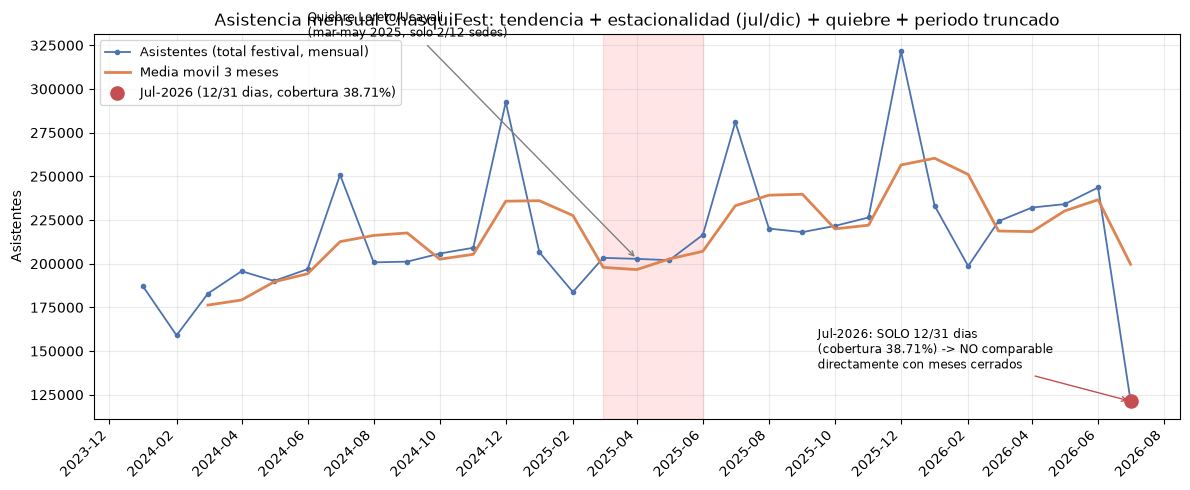

In [9]:

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(serie['mes'], serie['asistentes'], marker='o', ms=3, lw=1.3, color='#4C72B0', label='Asistentes (total festival, mensual)')
ax.plot(serie['mes'], serie['media_movil_3m'], lw=2, color='#DD8452', label='Media movil 3 meses')

# Banda del quiebre Loreto/Ucayali (afecta solo 2 de 12 sedes, por eso apenas se nota a nivel agregado)
ax.axvspan(pd.Timestamp('2025-03-01'), pd.Timestamp('2025-06-01'), color='red', alpha=0.10)
ax.annotate('Quiebre Loreto/Ucayali\n(mar-may 2025, solo 2/12 sedes)',
            xy=(pd.Timestamp('2025-04-01'), serie.loc[serie['mes']=='2025-04-01','asistentes'].values[0]),
            xytext=(pd.Timestamp('2024-06-01'), 330000),
            fontsize=8.5, arrowprops=dict(arrowstyle='->', color='gray'))

# Anotacion de julio 2026 truncado
jul26_val = serie.loc[serie['mes']=='2026-07-01', 'asistentes'].values[0]
ax.scatter([pd.Timestamp('2026-07-01')], [jul26_val], color='#C44E52', s=90, zorder=5, label='Jul-2026 (12/31 dias, cobertura 38.71%)')
ax.annotate('Jul-2026: SOLO 12/31 dias\n(cobertura 38.71%) -> NO comparable\ndirectamente con meses cerrados',
            xy=(pd.Timestamp('2026-07-01'), jul26_val),
            xytext=(pd.Timestamp('2025-09-15'), 140000),
            fontsize=8.5, arrowprops=dict(arrowstyle='->', color='#C44E52'))

ax.set_title('Asistencia mensual ChasquiFest: tendencia + estacionalidad (jul/dic) + quiebre + periodo truncado')
ax.set_ylabel('Asistentes')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45, ha='right')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('fig2_serie_quiebre_cobertura.png', dpi=110, bbox_inches='tight')
plt.show()



## Pregunta 3 — Comparación interperiodo (YoY válida para julio 2026)

### (1) Concepto técnico
Una comparación año contra año (YoY) solo es válida entre **periodos homólogos**: misma unidad de exposición (aquí, días observados). `LOOKUP(SUM([asistentes]), -12)` en una tabla mensual trae, para julio-2026, el valor 12 meses atrás = julio-2025 (281,044, con cobertura 100%). Compararlo directo contra julio-2026 (121,281, cobertura 38.71%) mezcla un mes de 31 días contra uno de 12 — **no son periodos homólogos** y la diferencia resultante (−56.8%) mide sobre todo la diferencia de cobertura, no de desempeño.

### (2) Evidencia — contraste explícito bruto vs. ritmo diario
- **Caída bruta:** num = `asistentes(Jul26) − asistentes(Jul25)` = 121,281 − 281,044 = −159,763; den = `asistentes(Jul25)` = 281,044 → **−56.8%**. Compara **totales de mes** (magnitudes con exposición distinta: 31 días vs 12 días).
- **Ritmo diario:** num = `asistentes(Jul26)/dias_observados(Jul26) − asistentes(Jul25)/dias_observados(Jul25)` = 10,106.75 − 9,065.94 = 1,040.80; den = `asistentes(Jul25)/dias_observados(Jul25)` = 9,065.94 → **+11.5%**. Compara **tasas por día** (controla la exposición).

**El signo se invierte (−56.8% → +11.5%) sin que ningún dato del CSV cambie.** Lo único que cambia es el **denominador**: "31 días fijos" (el mes completo del año anterior) vs "días realmente observados" (12, este año). Es la misma trampa que comparar las ventas totales de una tienda abierta 12 días del mes contra una tienda abierta los 31 días completos, sin normalizar por días de apertura.

### (3) Decisión de cálculo — 3 formas de construir un YoY válido
**(a) Días homólogos:** ideal = comparar los primeros 12 días de julio-2025 contra los 12 días observados de julio-2026. **Limitación de datos:** este CSV tiene granularidad **mensual × sede**, no diaria — no existe un campo que permita aislar "los primeros 12 días de julio-2025" directamente. Proxy calculado (asumiendo distribución uniforme dentro del mes): `ritmo_diario(Jul25) × 12 = 9,065.94 × 12 = 108,791.23` asistentes "equivalentes a 12 días". Comparado con el real de julio-2026 (121,281) → **+11.48%** (idéntico al cambio de ritmo diario, por construcción lineal). Límite explícito: asume que la afluencia diaria es uniforme dentro del mes (sin efecto fin de semana ni aceleración de cierre), supuesto no verificable sin datos diarios reales.

**(b) Esperar el cierre del mes:** posponer el YoY oficial hasta que `dias_observados(Jul26)=31`; mientras tanto reportar el ritmo diario como indicador provisional, no la variación bruta.

**(c) Proyectar (con incertidumbre declarada):** extrapolar `ritmo_diario(Jul26) × 31 = 10,106.75 × 31 = 313,309.25` asistentes proyectados. Vs. julio-2025 real (281,044) → **+11.48%**. Supuesto declarado: ritmo diario constante durante el resto del mes (sin aceleración de fin de mes ni feriados). **Incertidumbre:** es una proyección, no una observación — el número real de cierre podría diferir si hay estacionalidad intra-mes; no debe presentarse como cifra oficial, solo como rango orientativo con el ritmo diario como referencia central.

### (4) Fórmulas Tableau + símil pandas
```
// YoY bruto (NO valido si difiere cobertura)
(SUM([asistentes]) - LOOKUP(SUM([asistentes]), -12)) / LOOKUP(SUM([asistentes]), -12)

// Ritmo diario (version corregida por cobertura)
SUM([asistentes]) / SUM([dias_observados])
```
**Addressing:** along `Mes` continuo (SIN partición por año, para que −12 cruce el límite de año). **Orden:** `Mes` ascendente.

Pandas:
```python
lookup_12 = serie.set_index('mes')['asistentes'].shift(12)   # simil LOOKUP(..., -12)
ritmo = df.groupby(['anio','numero_mes']).apply(lambda g: g['asistentes'].sum() / g['dias_observados'].iloc[0])
```


In [10]:

# Contraste explicito: caida bruta vs ritmo diario, y las 3 alternativas de YoY valido
print("=== Contraste bruto vs ritmo diario ===")
print(f"Caida bruta   : ({tot26:,} - {tot25:,}) / {tot25:,} = {caida_bruta:+.2f}%   (num/den = totales de MES)")
print(f"Cambio ritmo  : ({ritmo26:,.2f} - {ritmo25:,.2f}) / {ritmo25:,.2f} = {cambio_ritmo:+.2f}%   (num/den = asistentes/DIA)")
print()

print("=== (a) Proxy de dias homologos (asume distribucion uniforme intramensual) ===")
proxy_12d = ritmo25 * 12
cambio_proxy = (tot26 - proxy_12d) / proxy_12d * 100
print(f"ritmo25 x 12 dias = {ritmo25:,.2f} x 12 = {proxy_12d:,.2f}  vs jul26 real = {tot26:,}  -> cambio = {cambio_proxy:+.2f}%")
print()

print("=== (c) Proyeccion a mes completo (con incertidumbre declarada) ===")
proy31 = ritmo26 * 31
cambio_proy = (proy31 - tot25) / tot25 * 100
print(f"ritmo26 x 31 dias = {ritmo26:,.2f} x 31 = {proy31:,.2f}  vs jul25 real = {tot25:,}  -> cambio = {cambio_proy:+.2f}%")
print("NOTA: (a) y (c) coinciden en magnitud (+11.48%) por construccion lineal; ambas son PROXIES, no observaciones.")
print()

print("=== LOOKUP(SUM([asistentes]), -12) ingenuo ===")
lookup_12 = serie.set_index('mes')['asistentes'].shift(12)
print(f"LOOKUP para jul-2026 trae jul-2025 = {lookup_12.loc['2026-07-01']:,.0f}  (cobertura 100%, 31 dias)")
print(f"Comparado directo contra jul-2026 real ({tot26:,}, cobertura 38.71%, 12 dias) -> periodos NO homologos.")


=== Contraste bruto vs ritmo diario ===
Caida bruta   : (121,281 - 281,044) / 281,044 = -56.85%   (num/den = totales de MES)
Cambio ritmo  : (10,106.75 - 9,065.94) / 9,065.94 = +11.48%   (num/den = asistentes/DIA)

=== (a) Proxy de dias homologos (asume distribucion uniforme intramensual) ===
ritmo25 x 12 dias = 9,065.94 x 12 = 108,791.23  vs jul26 real = 121,281  -> cambio = +11.48%

=== (c) Proyeccion a mes completo (con incertidumbre declarada) ===
ritmo26 x 31 dias = 10,106.75 x 31 = 313,309.25  vs jul25 real = 281,044  -> cambio = +11.48%
NOTA: (a) y (c) coinciden en magnitud (+11.48%) por construccion lineal; ambas son PROXIES, no observaciones.

=== LOOKUP(SUM([asistentes]), -12) ingenuo ===
LOOKUP para jul-2026 trae jul-2025 = 281,044  (cobertura 100%, 31 dias)
Comparado directo contra jul-2026 real (121,281, cobertura 38.71%, 12 dias) -> periodos NO homologos.


In [11]:

# KPI adicional de contexto: cumplimiento de meta (meta ya ajustada a dias observados) - respalda que jul-2026 NO esta en crisis
kpi_2026 = df[df['anio']==2026].groupby(['mes','numero_mes'], as_index=False)[['asistentes','meta_asistentes']].sum()
kpi_2026['cumplimiento_%'] = kpi_2026['asistentes'] / kpi_2026['meta_asistentes'] * 100
print("Cumplimiento de meta mensual 2026 (total festival, meta ajustada a dias_observados):")
print(kpi_2026.round(2).to_string(index=False))
print()
print(f"Jul-2026 cumplimiento = {kpi_2026.loc[kpi_2026['numero_mes']==7,'cumplimiento_%'].values[0]:.2f}% de la meta ajustada -> POR ENCIMA de 100%, consistente con el ritmo diario +11.5%, no con una 'caida de 57%'.")


Cumplimiento de meta mensual 2026 (total festival, meta ajustada a dias_observados):
       mes  numero_mes  asistentes  meta_asistentes  cumplimiento_%
2026-01-01           1      233162           233509           99.85
2026-02-01           2      198636           207009           95.96
2026-03-01           3      224315           236965           94.66
2026-04-01           4      232143           238692           97.26
2026-05-01           5      234073           240422           97.36
2026-06-01           6      243609           242150          100.60
2026-07-01           7      121281           120838          100.37

Jul-2026 cumplimiento = 100.37% de la meta ajustada -> POR ENCIMA de 100%, consistente con el ritmo diario +11.5%, no con una 'caida de 57%'.


/tmp/ipykernel_696237/3116519080.py:5: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(kpi_2026.round(2).to_string(index=False))



## Pregunta 4 — Comparar las 12 sedes

### (1) Concepto técnico
**Pequeños múltiplos con escala común** (mismo eje Y en los 12 paneles) responden **"¿qué sede aporta más volumen absoluto?"** — comparación de *magnitud*. **Pequeños múltiplos con índice base 100** (cada sede reescalada a su propio valor de referencia) responden **"¿qué sede creció, cayó o se recuperó en términos relativos?"** — comparación de *forma/recuperación*, independiente del tamaño. Esta segunda vista es la que se necesita cuando las sedes tienen tamaños muy distintos y existe un quiebre que solo afecta a algunas.

### (2) Evidencia con números reales
**Magnitud (escala común):** tamaño medio mensual 2025 — Lima (SED-01) = 38,557; Cusco (SED-06) = 23,500; Arequipa (SED-05) = 22,333; … ; Iquitos (SED-11) = 13,037; Pucallpa (SED-12) = 11,242 (la más pequeña). Lima es **3.4× más grande** que Pucallpa. En una vista de escala común, la caída de Iquitos/Pucallpa durante el quiebre (a ~7,100–8,518) queda visualmente aplastada contra el eje Y dominado por Lima — el quiebre casi no se nota.

**Recuperación relativa (índice base 100, referencia = enero-2025):** Iquitos cae a 63.5 (mar-25) → 63.3 (abr-25) → 55.6 (may-25), y se recupera a 101.9 en jun-25, alcanzando 125.8 en jul-25 (estacionalidad) y 151.0 en dic-25 (pico). Pucallpa: 66.1 → 63.2 → 63.6, recupera a 102.5 en jun-25, 154.0 en dic-25. Lima, en la misma ventana, solo fluctúa por estacionalidad normal (106.4 en mar-25, 99.9 en abr-25, 112.9 en may-25, sin ningún dip). El índice hace visible una **"V" clara de caída y recuperación en 3 meses** que la vista de escala común esconde por completo.

### (3) Decisión de diseño
- **Granularidad:** mantener 1 punto por mes × sede en ambas vistas (no agregar a trimestre/año) — 12 paneles (uno por sede) con el eje X = mes, ene-2024 a jul-2026.
- **Anotar el quiebre sin confundirlo con tendencia estructural:** banda sombreada (`axvspan`) entre 2025-03 y 2025-05, aplicada **solo** en los paneles de Loreto y Ucayali, con etiqueta explícita "Interrupción logística ficticia (evento puntual, 6/372 filas)" — distinta de la banda/anotación de estacionalidad (jul/dic, que sí es recurrente y estructural). En 2026 ambas sedes vuelven a "Sin quiebre registrado", confirmando que no es una tendencia nueva.

### (4) Límite/trade-off
El índice base 100 oculta la magnitud absoluta: una sede pequeña con alta variabilidad relativa puede parecer "más dramática" que Lima aunque mueva muchas menos personas en términos absolutos. Por eso ninguna de las dos vistas reemplaza a la otra — se presentan **una al lado de la otra**, cada una etiquetada con la pregunta que responde.

### BITÁCORA (Pregunta 4)
1. **Lectura inicial:** Lima domina el festival; las demás sedes parecen estancadas o irrelevantes.
2. **KPI decisor:** Índice de recuperación post-quiebre = (`asistentes_mes` / `asistentes_ene-2025`) × 100, mensual, por sede (Loreto/Ucayali), meta ≥ 100 para junio-2025.
3. **Giro analítico:** al indexar cada sede a base 100, Loreto y Ucayali muestran una V completa (63 → 101 en 3 meses) que la vista de escala común, dominada por Lima, no deja ver.
4. **Lectura revisada:** el quiebre fue real pero temporal; ambas sedes se recuperaron para junio-2025.
5. **Consecuencia:** el comité debería evaluar la resiliencia logística de Loreto/Ucayali (tiempo de recuperación) en vez de recortar presupuesto por "bajo desempeño" —una decisión que solo emerge al mirar recuperación relativa (índice base 100) y que la vista de magnitud absoluta (donde Lima domina) habría llevado a ignorar o mal-interpretar como debilidad estructural de la Selva.


In [12]:

# Magnitud: tamano medio 2025 por sede (para escala comun)
sede_size = df[df['anio']==2025].groupby(['sede_id','ciudad'])['asistentes'].mean().sort_values(ascending=False)
print("Tamano medio mensual 2025 por sede (magnitud, para pequenos multiplos de escala comun):")
print(sede_size.round(0).astype(int))
print()
print(f"Lima / Pucallpa = {sede_size.iloc[0] / sede_size.iloc[-1]:.2f}x")


Tamano medio mensual 2025 por sede (magnitud, para pequenos multiplos de escala comun):
sede_id  ciudad  
SED-01   Lima        38558
SED-06   Cusco       23500
SED-05   Arequipa    22333
SED-03   Trujillo    21163
SED-02   Piura       20577
SED-04   Chiclayo    17465
SED-07   Puno        16066
SED-09   Huancayo    15972
SED-11   Iquitos     13037
SED-10   Tarapoto    13032
SED-08   Ayacucho    12365
SED-12   Pucallpa    11242
Name: asistentes, dtype: int64

Lima / Pucallpa = 3.43x


In [13]:

# Indice base 100 (ref = ene-2025) para TODAS las sedes -> input de los pequenos multiplos
base_ene25 = df[(df['anio']==2025)&(df['numero_mes']==1)].set_index('sede_id')['asistentes']
df25 = df[df['anio']==2025].copy()
df25['indice_base100'] = df25.apply(lambda r: r['asistentes'] / base_ene25[r['sede_id']] * 100, axis=1)

pivot_idx = df25.pivot(index='mes', columns='sede_id', values='indice_base100')
print("Indice base 100 (ref=ene-2025) - marzo a junio 2025, todas las sedes:")
print(pivot_idx.loc['2025-03-01':'2025-06-01'].round(1))


Indice base 100 (ref=ene-2025) - marzo a junio 2025, todas las sedes:
sede_id     SED-01  SED-02  SED-03  SED-04  SED-05  SED-06  SED-07  SED-08  SED-09  SED-10  SED-11  SED-12
mes                                                                                                       
2025-03-01   106.4    99.5    92.9   106.1    99.6   105.7   105.9   102.3   110.1   102.5    63.5    66.1
2025-04-01    99.9    92.8    99.9   102.4    99.3   118.2   105.1    99.6   108.7   107.7    63.3    63.2
2025-05-01   112.9    95.1   102.8    98.6   102.8    98.4   106.9    98.1   103.9   102.0    55.6    63.6
2025-06-01   110.6    92.7    94.5   103.4   101.5   111.9   108.3   108.0   109.6   114.6   101.9   102.5


### Figura 3 — Pequeños múltiplos: escala común vs. índice base 100 (Lima, Iquitos, Pucallpa)

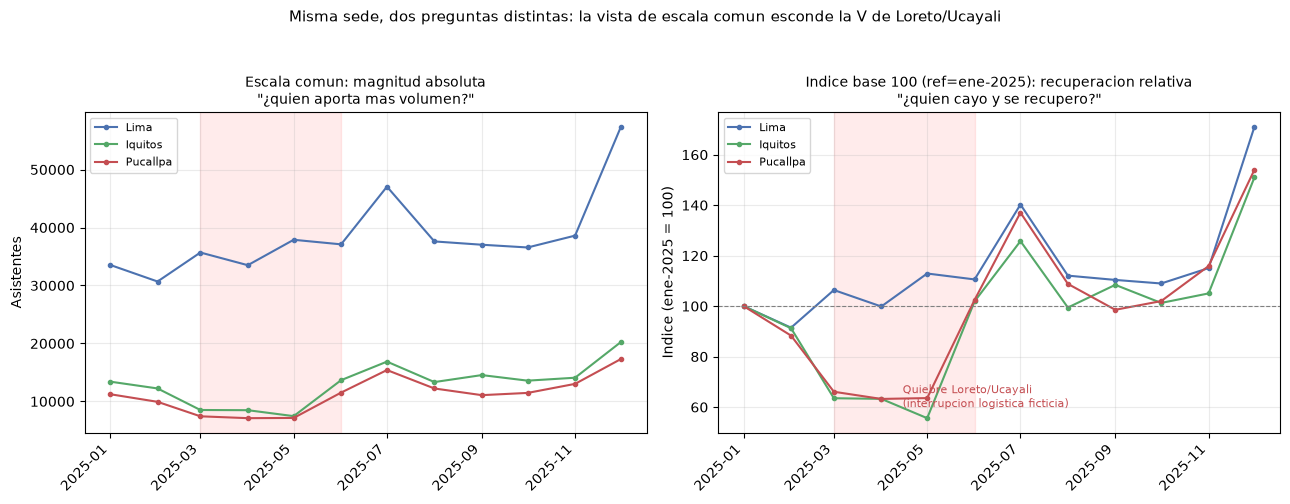

In [14]:

sel = ['SED-01', 'SED-11', 'SED-12']
labels = {'SED-01': 'Lima', 'SED-11': 'Iquitos', 'SED-12': 'Pucallpa'}
colors = {'SED-01': '#4C72B0', 'SED-11': '#55A868', 'SED-12': '#C44E52'}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# Panel A: escala comun (magnitud absoluta)
ax = axes[0]
for s in sel:
    d = df25[df25['sede_id']==s].sort_values('mes')
    ax.plot(d['mes'], d['asistentes'], marker='o', ms=3, label=labels[s], color=colors[s])
ax.axvspan(pd.Timestamp('2025-03-01'), pd.Timestamp('2025-06-01'), color='red', alpha=0.08)
ax.set_title('Escala comun: magnitud absoluta\n"¿quien aporta mas volumen?"', fontsize=10)
ax.set_ylabel('Asistentes')
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Panel B: indice base 100 (recuperacion relativa)
ax = axes[1]
for s in sel:
    d = df25[df25['sede_id']==s].sort_values('mes')
    ax.plot(d['mes'], d['indice_base100'], marker='o', ms=3, label=labels[s], color=colors[s])
ax.axhline(100, color='gray', lw=0.8, ls='--')
ax.axvspan(pd.Timestamp('2025-03-01'), pd.Timestamp('2025-06-01'), color='red', alpha=0.08)
ax.annotate('Quiebre Loreto/Ucayali\n(interrupcion logistica ficticia)', xy=(pd.Timestamp('2025-04-15'), 60),
            fontsize=8, color='#C44E52')
ax.set_title('Indice base 100 (ref=ene-2025): recuperacion relativa\n"¿quien cayo y se recupero?"', fontsize=10)
ax.set_ylabel('Indice (ene-2025 = 100)')
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

fig.suptitle('Misma sede, dos preguntas distintas: la vista de escala comun esconde la V de Loreto/Ucayali', fontsize=11, y=1.04)
plt.tight_layout()
plt.savefig('fig3_pequenos_multiplos.png', dpi=110, bbox_inches='tight')
plt.show()



## Cierre

Los cinco números ancla del enunciado se reprodujeron exactamente a partir del CSV: total jul-2025 = 281,044; total jul-2026 = 121,281; cobertura jul-2026 = 38.71%; caída bruta = −56.85% (≈ el titular −57%); ritmo diario +11.48%. El hallazgo central es metodológico, no de negocio: **el "colapso" de julio-2026 es un artefacto de comparar un mes truncado (12/31 días) contra un mes cerrado, no una caída real de asistencia** — corregido por cobertura, el ritmo diario y el cumplimiento de meta (num = SUM(asistentes jul-2026) = 121,281 / den = SUM(meta_asistentes jul-2026) = 120,838 → 100.37%) muestran a ChasquiFest por encima del año anterior.


## Resumen visual — comparar ritmo, no meses incompletos
Cada línea conecta el promedio diario de una sede en julio de 2025 con julio de 2026.

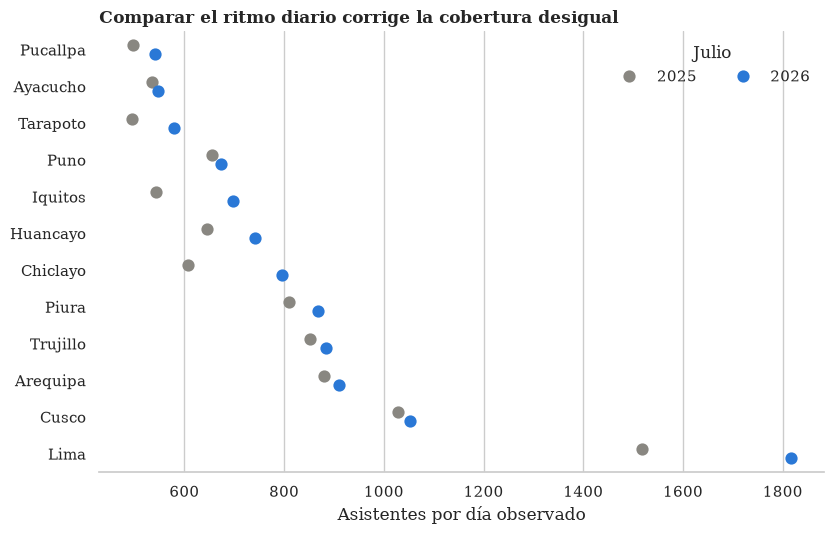

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
d = pd.read_csv('../data/caso3_asistencia_mensual_chasquifest.csv')
j = d[(d['numero_mes'] == 7) & d['anio'].isin([2025, 2026])].copy(); j['ritmo'] = j['asistentes']/j['dias_observados']
orden = j[j['anio'] == 2026].sort_values('ritmo')['ciudad']
sns.set_theme(style='whitegrid', font='serif')
fig, ax = plt.subplots(figsize=(8.5, 5.5))
sns.pointplot(data=j, y='ciudad', x='ritmo', hue='anio', order=orden, palette=['#898781','#2a78d6'], linestyles='', dodge=.25, ax=ax)
ax.set_xlabel('Asistentes por día observado'); ax.set_ylabel('')
ax.set_title('Comparar el ritmo diario corrige la cobertura desigual', loc='left', fontweight='bold')
ax.legend(title='Julio', frameon=False, ncol=2); sns.despine(left=True)
plt.tight_layout(); plt.savefig('fig4_ritmo_diario_por_sede.png', dpi=130, bbox_inches='tight'); plt.show()
